# 11 — The two operating points, side by side

Notebooks 07 and 08 each report **one** configuration of the third experiment.
This one is the only place they meet, and it exists because neither is the
result on its own.

| configuration | κ    | arbitrage share, ETH/SHIB | pre-registration                               |
| ------------- | ---- | ------------------------- | ---------------------------------------------- |
| headline      | 1.0  | 15%                       | `2026-08-09-uu-matrix-preregistration.md`      |
| informed      | 0.1  | 56%                       | `2026-08-11-informed-share-preregistration.md` |

The share is measured **at the baseline policy**, not pooled over all twelve.
Pooling raises it to 22% and 62% by averaging in `MyHook@10000`, whose fee is
high enough to price most retail out — that is a fact about the policy, not
about the configuration, and the configuration is what these two rows name.

**Why two.** κ was calibrated by a rule about *turnover* — mean daily uninformed
volume over 2024 equals one basket — and the mechanism under test does not
depend on turnover. It depends on the **share of flow that is informed**, and at
the calibrated κ that share came out at 15%. The κ sweep (notebook 09) showed
the advantage of an adaptive fee rising steeply as the share rises, which means
the headline configuration sits at the *weakest* point of the curve.

That is not a reason to move the headline. κ = 1.0 is the calibrated value, and
picking an operating point because it flatters the result is exactly what
pre-registration exists to prevent. It is a reason to report a second point
where both flows are comparably present — and to let a reader see that the
unfavourable configuration was kept as the headline anyway.

**Needs:** both matrices — `results-uu/summary.csv` and
`results-uu/turnover-0.1/summary.csv`.


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.aggregate import (
    VOLATILE_PAIRS,
    paired_against_baseline,
    summarise_strata,
)
from experiments.figures import operating_points
from experiments.stats import analyse

FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)

# Same keys as `UU_CONFIG` in notebooks 07 and 08; both are loaded here.
POINTS = {
    "κ = 1.0  (arbitrage 15% of ETH/SHIB volume)": ROOT / "results-uu",
    "κ = 0.1  (arbitrage 56% of ETH/SHIB volume)": (
        ROOT / "results-uu" / "turnover-0.1"
    ),
}

frames = {}
for label, directory in POINTS.items():
    frames[label] = pd.read_csv(directory / "summary.csv")
    errors = int(frames[label]["error"].notna().sum())
    assert errors == 0, f"{label}: {errors} failed cells"
    print(f"{label}: {len(frames[label])} cells, 0 errors")


κ = 1.0  (arbitrage 15% of ETH/SHIB volume): 7776 cells, 0 errors
κ = 0.1  (arbitrage 56% of ETH/SHIB volume): 7776 cells, 0 errors


## 1. What actually differs between them

The two runs are identical in every respect but κ — same seed, same windows,
same gas scenarios, same `r`, same λ, same contracts. So the flow composition
below is the whole of the difference, and everything further down is a
consequence of it.


In [2]:
# Measured at the baseline, for the reason given above.
composition = []
for label, frame in frames.items():
    baseline = frame[frame["policy"] == "MyHook@3000"]
    for pair, group in baseline.groupby("pair"):
        arb = group["arb_volume"].sum()
        uu = group["uu_volume"].sum()
        composition.append(
            {
                "configuration": label,
                "pair": pair,
                "arbitrage_share": arb / (arb + uu),
                "uu_participation": group["uu_participation"].mean(),
                "trades_per_cell": group["trade_count"].mean(),
            }
        )
composition = pd.DataFrame(composition)
composition.pivot(
    index="pair", columns="configuration", values="arbitrage_share"
).round(3)


configuration,κ = 0.1 (arbitrage 56% of ETH/SHIB volume),κ = 1.0 (arbitrage 15% of ETH/SHIB volume)
pair,,
ETH/SHIB,0.558,0.148
ETH/USDC,0.388,0.113
USDC/USDT,0.037,0.110


## 2. The baseline itself, before any comparison

This is the number that changes the reading of everything else, and it is easy
to state carelessly. Report the mean **and** the median: they disagree in sign
at κ = 0.1, and the disagreement is the finding, not a rounding detail.


In [3]:
baselines = []
for label, frame in frames.items():
    base = frame[frame["policy"] == "MyHook@3000"]
    volatile = base[base["pair"].isin(VOLATILE_PAIRS)]
    baselines.append(
        {
            "configuration": label,
            "mean_all_pairs": base["net_result"].mean(),
            "median_all_pairs": base["net_result"].median(),
            "mean_volatile": volatile["net_result"].mean(),
            "median_volatile": volatile["net_result"].median(),
        }
    )
baselines = pd.DataFrame(baselines).set_index("configuration")
baselines.round(0).astype(int)


,mean_all_pairs,median_all_pairs,mean_volatile,median_volatile
configuration,,,,
κ = 1.0 (arbitrage 15% of ETH/SHIB volume),13002,12031,13318,12500
κ = 0.1 (arbitrage 56% of ETH/SHIB volume),-488,1201,-1416,1317


At κ = 0.1 the mean is **−488** USDT per window and the median is **+1,201**.
Both are true and they say different things: the typical day still makes money,
and a minority of days lose enough to take the average below zero. The mean is
what an LP holding the position through the whole year experiences, so "the LP
loses money at this mix" is the fair summary — but it must be said with the
median beside it, or it reads as "every day is a loss", which is false.

This also breaks the second pre-registration's declared prediction *as written*.
It said the advantage would be "roughly +10% of the baseline". A percentage of a
negative baseline is not interpretable and dividing by it flips signs, so the
prediction is reported as one whose units did not survive contact with the
configuration — neither confirmed nor refuted. Everything below is therefore in
absolute USDT.


## 3. The comparison

The unit of analysis is the pre-registered **stratum** — policy × pair × regime
× gas — and there are 18 per policy across the two volatile pairs. The headline
number is the median across those 18, with a percentile bootstrap resampling
*strata*.

Resampling strata rather than the 432 individual windows is the conservative
choice and it is deliberate: pooling windows gives an interval about three times
narrower by treating three gas scenarios of the same window as three independent
observations, which they are not. What we want to know is whether the effect
survives a change of regime, pair, or gas price.


In [4]:
summaries = []
for label, frame in frames.items():
    tests = analyse(paired_against_baseline(frame), value="net_result_delta")
    summary = summarise_strata(tests)
    summary["configuration"] = label
    summary["subtitle"] = (
        f"static 30 bps baseline: "
        f"{baselines.loc[label, 'mean_all_pairs']:+,.0f} USDT per window (mean)"
    )
    summaries.append(summary)

table = pd.concat(summaries, ignore_index=True)
table.pivot(index="policy", columns="configuration", values="median").round(0)


configuration,κ = 0.1 (arbitrage 56% of ETH/SHIB volume),κ = 1.0 (arbitrage 15% of ETH/SHIB volume)
policy,,
ABHook,-47.0,-254.0
BAHook,155.0,114.0
DAHook,184.0,341.0
MEVChargeHook,-59.0,-847.0
MEVChargeHookFixed,-52.0,-308.0
MyHook@10000,59.0,-3535.0
MyHook@500,-1337.0,-8480.0
MyHook@6000,193.0,-81.0
PegCapture,-487.0,-4602.0


In [5]:
table[
    ["configuration", "policy", "median", "ci_low", "ci_high",
     "strata_positive", "ci_excludes_zero"]
].round(1)


,configuration,policy,median,ci_low,ci_high,strata_positive,ci_excludes_zero
0,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),DAHook,341.3,263.5,672.2,17,True
1,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),BAHook,114.0,-107.6,549.0,12,False
2,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),MyHook@6000,-80.9,-196.7,279.8,6,False
3,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),ABHook,-253.6,-440.2,-191.0,0,True
4,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),MEVChargeHookFixed,-308.1,-498.5,-150.7,0,True
5,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),MEVChargeHook,-846.9,-1399.3,-656.5,2,True
6,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),MyHook@10000,-3534.6,-4600.8,-2977.2,0,True
7,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),PegCapture,-4602.0,-5847.4,-4144.2,0,True
8,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),MyHook@500,-8479.6,-14999.9,-6576.5,0,True
9,κ = 1.0 (arbitrage 15% of ETH/SHIB volume),VolatilityHook,-8716.1,-15772.2,-6785.9,0,True


## 4. The figure

`uu_operating_points.pdf`. Two columns, one per configuration; two rows, split
by effect size so the contest between the adaptive policies and the baseline is
not crushed by `PegDefence` losing eleven thousand USDT a window. Every policy
appears exactly once. A filled marker means the bootstrap interval excludes
zero.


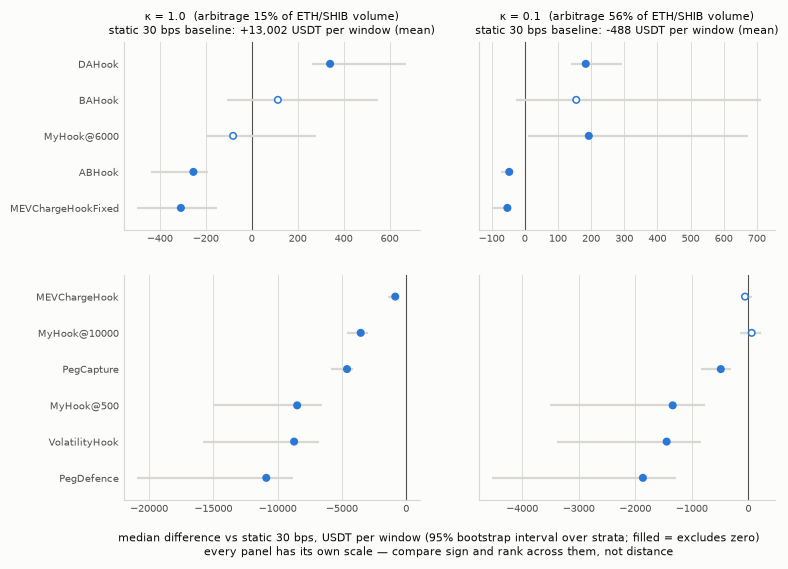

In [6]:
from IPython.display import Image, display

operating_points(table, FIGURES / "uu_operating_points.pdf")
operating_points(table, FIGURES / "uu_operating_points.png")
display(Image(filename=str(FIGURES / "uu_operating_points.png")))


## 5. What survives both configurations

A claim that holds at one operating point and not the other is a claim about
that operating point, not about the policy. These are the ones that hold at
both.


In [7]:
verdicts = table.pivot(index="policy", columns="configuration", values="median")
clears = table.pivot(index="policy", columns="configuration", values="ci_excludes_zero")

both_positive = (verdicts > 0).all(axis=1) & clears.all(axis=1)
both_negative = (verdicts < 0).all(axis=1) & clears.all(axis=1)
covers_zero = ~clears.any(axis=1)

print("beats the baseline at BOTH points, interval clearing zero at both:")
print("  " + ", ".join(verdicts.index[both_positive]) or "  none")
print("\nloses at BOTH points, interval clearing zero at both:")
print("  " + ", ".join(verdicts.index[both_negative]))
print("\ninterval covers zero at BOTH points -- no size claim either way:")
print("  " + ", ".join(verdicts.index[covers_zero]))


beats the baseline at BOTH points, interval clearing zero at both:
  DAHook

loses at BOTH points, interval clearing zero at both:
  ABHook, MEVChargeHookFixed, MyHook@500, PegCapture, PegDefence, VolatilityHook

interval covers zero at BOTH points -- no size claim either way:
  BAHook


### The reading

**`DAHook` is the only policy whose interval clears zero on the winning side at
both operating points.** It is the one result of the third experiment that does
not depend on the flow mix chosen.

**`BAHook`'s interval covers zero at both** (−108 to +549, and −28 to +713),
despite being significant in 10 of 18 strata at each. That is the whole reason
the bootstrap was added: significance ranks by *consistency*, the interval ranks
by *size with its uncertainty attached*, and on this comparison they disagree.
`BAHook` is not a winner on effect size at either point, and the earlier reading
that promoted it was reading a p-value as though it were a measurement.

**`ABHook` loses at both**, at every κ in the sweep, and at every seed.

And the direction of the whole thing: in **dollars** the advantage is *smaller*
at the higher informed share, not larger — the opposite of what the κ sweep
suggested. The sweep measured a ratio to a baseline that was still positive on
its 24 windows and single gas scenario; the full matrix at three gas scenarios
drives the baseline mean below zero and the ratio stops meaning anything. The
defensible statement is:

> at a retail-dominated mix the LP profits and the adaptive policies add a few
> hundred USDT a day on top; at a mix where arbitrage is about half the volume
> the LP loses money on average and the adaptive policies reduce that loss by
> roughly a third without eliminating it.

Not "the dynamic policies beat a static fee".
